# Assignment 2: Classify the solar wind into geoeffective vs non-geoeffective

## Due on Wed 11th February at 12pm
### Submit your jupyter notebook on QMPlus (tab Assessments) with name LAST_NAME_Assignment_2.ipynb

## Solar wind

The **solar wind** is a continuous stream of charged particles, primarily electrons and protons, emitted by the Sun's outer atmosphere, the **corona**. This plasma flows outward through the solar system, carrying the Sun's magnetic field with it, and plays a central role in shaping the space environment around planets and other celestial bodies.

### Key Characteristics of the Solar Wind:
1. **Composition**:
   - Mostly **protons** (hydrogen nuclei) and **electrons**.
   - Contains a smaller fraction of **helium nuclei** (alpha particles) and trace amounts of heavier ions.

2. **Speed**:
   - Varies between **300–800 km/s**.
   - Divided into:
     - **Slow solar wind**: ~300–500 km/s, typically originating from the Sun's equatorial regions or near the edges of coronal holes.
     - **Fast solar wind**: ~500–800 km/s, associated with open magnetic field lines in coronal holes.

3. **Temperature**:
   - Extremely hot, with ion temperatures ranging from **10,000 K to over 1 million K**.
   - Electrons are generally hotter than ions.

4. **Magnetic Field**:
   - The solar wind carries the Sun’s magnetic field into space, forming the **interplanetary magnetic field (IMF)**.
   - The IMF is embedded in the plasma due to the Sun's rotation, creating a **spiral structure** (Parker spiral).

5. **Density**:
   - Typically 5–10 particles per cubic centimeter near Earth but decreases with distance from the Sun.

### Origin of the Solar Wind:
- The solar wind is generated in the **solar corona**, where the Sun's high temperatures give particles enough energy to overcome the Sun’s gravitational pull.
- Magnetic reconnection and wave-particle interactions are believed to contribute to the acceleration of the solar wind.

### Interaction with the Solar System:
1. **Heliosphere**:
   - The solar wind creates a bubble-like region around the Sun called the **heliosphere**, which extends far beyond the orbit of Pluto.
   - The **termination shock** marks where the solar wind slows down as it encounters the interstellar medium.

2. **Planetary Magnetospheres**:
   - The solar wind interacts with planetary magnetic fields, shaping magnetospheres and causing phenomena like auroras.

3. **Space Weather**:
   - Variations in the solar wind, especially during solar storms or coronal mass ejections (CMEs), can impact satellites, power grids, and communication systems on Earth.

### Importance of Studying the Solar Wind:
Understanding the solar wind is crucial for:
- Predicting space weather and protecting technology.
- Exploring how the Sun influences the solar system.
- Investigating fundamental plasma physics processes.

Space missions like **Parker Solar Probe** and **Solar Orbiter** are providing unprecedented insights into the solar wind's origin and dynamics.

## Geoeffectiveness

The **geoeffectiveness of the solar wind** refers to its ability to influence Earth's magnetosphere and ionosphere, driving geomagnetic activity such as auroras, magnetic storms, and other space weather phenomena. This effectiveness is determined by the solar wind's physical properties and how they interact with Earth's magnetic field. Key factors include:

### 1. **Interplanetary Magnetic Field (IMF) Orientation**
   - The orientation of the IMF, particularly its southward component ($B_z$) in the Geocentric Solar Magnetospheric (GSM) coordinate system, is critical.
   - A southward $B_z$ reconnects with Earth's northward magnetic field, allowing energy and plasma from the solar wind to enter the magnetosphere.

### 2. **Solar Wind Speed**
   - Higher solar wind speeds increase geoeffectiveness by enhancing the energy transfer rate into the magnetosphere.
   - Fast solar wind streams (e.g., from coronal holes) and Coronal Mass Ejections (CMEs) often drive intense geomagnetic storms.

### 3. **Solar Wind Density**
   - Elevated particle density contributes to stronger compression of the magnetosphere, intensifying geomagnetic effects.

### 4. **Dynamic Pressure**
   - The solar wind's dynamic pressure (\( P = \rho v^2 \), where \( \rho \) is density and \( v \) is speed) directly affects magnetospheric compression and geomagnetic activity.

### Geoeffective Phenomena
- **Auroras**: Caused by charged particles precipitating into the polar regions.
- **Geomagnetic Storms**: Global disturbances in Earth's magnetic field, often driven by CMEs or high-speed streams.
- **Substorms**: Localized disturbances in the magnetosphere, usually linked to energy release during reconnection events.

### Measuring Geoeffectiveness
- **Kp Index**: Measures global geomagnetic activity on a scale from 0 to 9.
- **Dst Index**: Indicates the intensity of the ring current, associated with geomagnetic storms.
- **Auroral Electrojet (AE) Index**: Reflects substorm activity.

Understanding the geoeffectiveness of the solar wind is crucial for space weather forecasting, which protects satellites, power grids, and other technologies from adverse effects.

# <span style="color:red">Task:</span>

### The task is to train a classifier that takes as inputs a few features of solar wind and predicts the probability of a geomagnetic storm. For simplicity, we define as storm a value of Dst < -100

The datasets to be used are:

* omni_data_train.csv (for training)
* omni_data_train.csv (for testing)

The dataset has been adapted from here:
https://spdf.gsfc.nasa.gov/pub/data/omni/low_res_omni/omni2.text 

Corrupted values are filled with "fill values", equivalent to NaN.
You need to remove them. Here is the list of variables:

|FORMAT | Fill Value |        MEANING          |        UNITS |
| ------| ------| ------------| -------------|
|F6.1 | 999.9   |  Field Magnitude Average |B|   |    1/N SUM |B|, nT|
|F6.1 | 999.9   |  Bz GSM               |             nT |
|F9.0 | 9999999.|  Proton temperature (Temp)  |               Degrees, K |
|F6.1 | 999.9   |  Proton Density (N)      |            N/cm^3 |
|F6.0 | 9999.   |  Plasma (Flow) speed (V)   |              km/s |
|I6   | 99999   |  DST Index             |       nT  |

### Score

Because the dataset is very imbalanced (negatives>>positives), we define the final score of a classifier as the product of recall and precision:

In [1]:
# Define the score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def print_metrics(y, y_pred, y_prob):
    # 1. Accuracy
    accuracy = accuracy_score(y, y_pred)
    print(f"Accuracy: {accuracy:.2f}")

    # 2. Precision
    precision = precision_score(y, y_pred)
    print(f"Precision: {precision:.2f}")

    # 3. Recall (Sensitivity)
    recall = recall_score(y, y_pred)
    print(f"Recall (Sensitivity): {recall:.2f}")

    # 4. F1 Score
    f1 = f1_score(y, y_pred)
    print(f"F1 Score: {f1:.2f}")

    # 5. ROC-AUC Score
    roc_auc = roc_auc_score(y, y_prob)
    print(f"ROC-AUC Score: {roc_auc:.2f}")

    # 6. Confusion Matrix
    conf_matrix = confusion_matrix(y, y_pred)
    print("Confusion Matrix:")
    print(conf_matrix)

    score = recall*precision

    print(f"Score =  {score:.4f}")
    
    return score

### Sub-tasks:

#### 1) Define as 'storms' (positive) all labels with Dst<-100
#### 2) Show that the solar wind speed (V) by itself is not a good discriminator between storms and non-storms. You can do this graphically
#### 3) Train a Naive Bayes classifier
#### 4) Show that NB is equivalent to a classifier based on Gaussian Mixture model with 1 component per class and diagonal covariance
#### 5) Show that a GMM with full covariance and multiple components outperform a Naive Bayes classifier
#### 6) Train your best model and report the final score on the test set

---------------train dataset---------------

[nt] shape before drop: (499656, 7)
[nt] overall NaNs: 678959
[train] NaNs per column:
time         0
B       123472
Bz      123498
Temp    160693
N       143795
V       127501
Dst          0
dtype: int64
[train] rows with at least 1 NaN: 176072
[train] percentage of rows with at least 1 NaN: 35.24%
---------------test dataset---------------

[nt] shape before drop: (43848, 7)
[nt] overall NaNs: 9365
[test] NaNs per column:
time       0
B       2421
Bz      2421
Temp    1356
N       1364
V       1337
Dst      466
dtype: int64
[test] rows with at least 1 NaN: 2700
[test] percentage of rows with at least 1 NaN: 6.16%



---------------------Sub task 2: Distribution of Solar Wind Speed V for Storms and Non-Storms---------------------


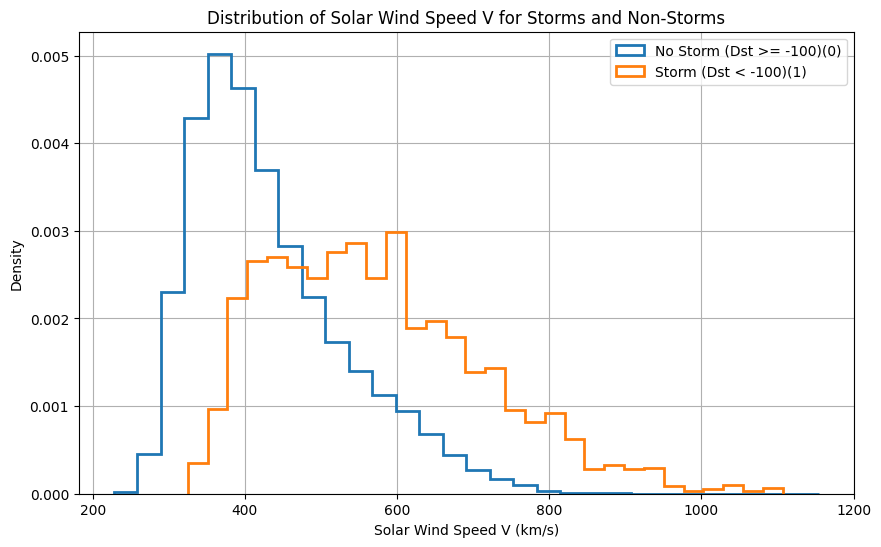

From the histogram we can see that solar wind speed (V) alone is not a good discriminator between storms and non-storms, as the distributions for both classes overlap significantly.



---------------------Sub task 3: Naive Bayes Classifier Performance---------------------
Accuracy: 0.9881
Precision: 0.2146
Recall: 0.5864
F1 Score: 0.3142
ROC AUC: 0.9854
Confusion Matrix:
[[40547   410]
 [   79   112]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     40957
           1       0.21      0.59      0.31       191

    accuracy                           0.99     41148
   macro avg       0.61      0.79      0.65     41148
weighted avg       0.99      0.99      0.99     41148




---------------------Sub task 4: NB vs GMM with 1 component per class and diagonal covariance---------------------
NB accuracy: 0.9881
GMM accuracy: 0.9780
Agreement between NB and GMM predictions: 0.9881
If agreement is close to 1, it sugge

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.mixture import GaussianMixture

#Prepare raw df (remove NaNs, sort by time, etc.)
def dataset_preprocessing():
    try:
        root_dir = os.getcwd() 
        train_df = pd.read_csv(os.path.join(root_dir, "data/omni_data_train.csv"))
        test_df = pd.read_csv(os.path.join(root_dir, "data/omni_data_test.csv"))
    except Exception as e:
        print(f"Error loading data: {e}")
        return None, None
    
    nan_map = {
        'B': 999.9,
        'Bz': 999.9,
        'Temp': 9999999,
        'N': 999.9,
        'V': 9999,
        'Dst': 99999
    }

    for name, df in [("train",train_df), ("test", test_df)]:
        df["time"] = pd.to_datetime(df["time"], format='%d-%b-%Y %H:%M:%S', errors='coerce')
        df.sort_values("time", inplace=True)
        for col, nan_value in nan_map.items():
            df[col] = df[col].replace(nan_value, np.nan)

        print(f"---------------{name} dataset---------------")
        
        print(f"\n[{os.name}] shape before drop: {df.shape}")

        overall_nans = df.isna().sum().sum()
        print(f"[{name}] overall NaNs: {overall_nans}")
        print(f"[{name}] NaNs per column:")
        print(df.isna().sum())

        nans_per_row = df.isna().sum(axis=1)

        rows_with_nan = (nans_per_row > 0).sum()
        print(f"[{name}] rows with at least 1 NaN: {rows_with_nan}")
        precentage_rows_with_nan = (rows_with_nan / len(df)) * 100
        print(f"[{name}] percentage of rows with at least 1 NaN: {precentage_rows_with_nan:.2f}%")
        
        df.dropna(subset= nan_map.keys(), inplace=True)
    
    print('\n\n')
    return train_df, test_df

#1:Define as 'storms' (positive) all labels with Dst<-100
def sub_task1(train_df, test_df):    
    train_df["storm"] = (train_df["Dst"] < -100).astype(int)
    test_df["storm"] = (test_df["Dst"] < -100).astype(int)

    x_train = train_df.drop(columns=["time", "Dst", "storm"])
    y_train = train_df["storm"]

    x_test = test_df.drop(columns=["time", "Dst", "storm"])
    y_test = test_df["storm"]

    return x_train, y_train, x_test, y_test

#2:Show that the solar wind speed (V) by itself is not a good discriminator between storms and non-storms. You can do this graphically
def sub_task2(x_train, y_train, x_test, y_test):
    x_set = pd.concat([x_train, x_test], ignore_index=True)
    y_set = pd.concat([y_train, y_test], ignore_index=True)
    no_storm = x_set.loc[y_set == 0, "V"]
    storm = x_set.loc[y_set == 1, "V"]

    print(f"---------------------Sub task 2: Distribution of Solar Wind Speed V for Storms and Non-Storms---------------------")

    plt.figure(figsize=(10, 6))
    plt.hist(no_storm, bins=30, density=True, histtype='step', linewidth=2, label='No Storm (Dst >= -100)(0)')
    plt.hist(storm, bins=30, density=True, histtype='step', linewidth=2, label='Storm (Dst < -100)(1)')
    plt.xlabel('Solar Wind Speed V (km/s)')
    plt.ylabel('Density')
    plt.title('Distribution of Solar Wind Speed V for Storms and Non-Storms')
    plt.legend()
    plt.grid()
    plt.show()

    print("From the histogram we can see that solar wind speed (V) alone is not a good discriminator between storms and non-storms, as the distributions for both classes overlap significantly.")
    print('\n\n')

#3:Train a Naive Bayes classifier
def sub_task3(x_train, y_train, x_test, y_test):
    nb = GaussianNB()
    nb.fit(x_train, y_train)

    y_pred = nb.predict(x_test)
    y_prob = nb.predict_proba(x_test)[:, 1]

    print(f"---------------------Sub task 3: Naive Bayes Classifier Performance---------------------")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print('\n\n')

    return y_pred, y_prob

#4:Show that NB is equivalent to a classifier based on Gaussian Mixture model with 1 component per class and diagonal covariance
def sub_task4(x_train, y_train, x_test, y_test):
    nb = GaussianNB()
    nb.fit(x_train, y_train)
    y_pred_nb = nb.predict(x_test)
    acc_nb = accuracy_score(y_test, y_pred_nb)

    x0 = x_train[y_train == 0]
    x1 = x_train[y_train == 1]

    gmm0 = GaussianMixture(n_components=1, covariance_type='diag', random_state=2003)
    gmm1 = GaussianMixture(n_components=1, covariance_type='diag', random_state=2003)
    gmm0.fit(x0)
    gmm1.fit(x1)

    p0 = (y_train == 0).mean()
    p1 = (y_train == 1).mean()

    log_prob0 = gmm0.score_samples(x_test) + np.log(p0)
    log_prob1 = gmm1.score_samples(x_test) + np.log(p1)

    y_pred_gmm = (log_prob1 > log_prob0).astype(int)
    acc_gmm = accuracy_score(y_test, y_pred_gmm)

    agreement = np.mean(y_pred_nb == y_pred_gmm)

    print(f"---------------------Sub task 4: NB vs GMM with 1 component per class and diagonal covariance---------------------")
    print(f"NB accuracy: {acc_nb:.4f}")
    print(f"GMM accuracy: {acc_gmm:.4f}")
    print(f"Agreement between NB and GMM predictions: {agreement:.4f}")
    print("If agreement is close to 1, it suggests that NB and GMM with 1 component per class and diagonal covariance are making similar predictions, supporting the claim of equivalence.")
    print('\n\n')

#5:Show that a GMM with full covariance and multiple components outperform a Naive Bayes classifier
def sub_task5(x_train, y_train, x_test, y_test):
    print(f"---------------------Sub task 5: GMM with full covariance and multiple components vs NB---------------------")
    nb = GaussianNB()
    nb.fit(x_train, y_train)
    nb_pred = nb.predict(x_test)
    nb_prob = nb.predict_proba(x_test)[:, 1]

    x0 = x_train[y_train == 0]
    x1 = x_train[y_train == 1]

    p0 = (y_train == 0).mean()
    p1 = (y_train == 1).mean()

    gmm0 = GaussianMixture(n_components=3, covariance_type='full', reg_covar=1e-6, random_state=2003)
    gmm1 = GaussianMixture(n_components=3, covariance_type='full', reg_covar=1e-6, random_state=2003)
    gmm0.fit(x0)
    gmm1.fit(x1)

    log_s0 = gmm0.score_samples(x_test) + np.log(p0)
    log_s1 = gmm1.score_samples(x_test) + np.log(p1)

    gmm_pred = (log_s1 > log_s0).astype(int)

    m = np.maximum(log_s0, log_s1)
    prob0 = np.exp(log_s0 - m)
    prob1 = np.exp(log_s1 - m)
    gmm_prob = prob1 / (prob0 + prob1)

    nb_f1 = f1_score(y_test, nb_pred, zero_division=0)
    gmm_f1 = f1_score(y_test, gmm_pred, zero_division=0)

    print(f"NB  -> Acc:{accuracy_score(y_test, nb_pred):.4f} "
          f"Prec:{precision_score(y_test, nb_pred, zero_division=0):.4f} "
          f"Rec:{recall_score(y_test, nb_pred, zero_division=0):.4f} "
          f"F1:{nb_f1:.4f} AUC:{roc_auc_score(y_test, nb_prob):.4f}")

    print(f"GMM -> Acc:{accuracy_score(y_test, gmm_pred):.4f} "
          f"Prec:{precision_score(y_test, gmm_pred, zero_division=0):.4f} "
          f"Rec:{recall_score(y_test, gmm_pred, zero_division=0):.4f} "
          f"F1:{gmm_f1:.4f} AUC:{roc_auc_score(y_test, gmm_prob):.4f}")

    if gmm_f1 > nb_f1:
        print("Conclusion: GMM(full covariance, multiple components) outperforms NB by F1.")
        best_model = ("gmm", gmm0, gmm1, p0, p1)  
    else:
        print("Conclusion: With current n_components, GMM does not outperform NB by F1.")
        best_model = nb

    print('\n\n')

    return best_model

#6:Train your best model and report the final score on the test set
def sub_task6(best_model, x_train, y_train, x_test, y_test):
    print("---------------------Sub task 6: Final Model Training and Evaluation---------------------")
    if isinstance(best_model, tuple) and best_model[0] == "gmm":
        _, gmm0, gmm1, p0, p1 = best_model
        log_prob0 = gmm0.score_samples(x_test) + np.log(p0)
        log_prob1 = gmm1.score_samples(x_test) + np.log(p1)
        y_pred = (log_prob1 > log_prob0).astype(int)

        m = np.maximum(log_prob0, log_prob1)
        prob0 = np.exp(log_prob0 - m)
        prob1 = np.exp(log_prob1 - m)
        y_prob = prob1 / (prob0 + prob1)
    else:
        best_model = best_model if best_model is not None else GaussianNB()
        best_model.fit(x_train, y_train)
        y_pred = best_model.predict(x_test)
        y_prob = best_model.predict_proba(x_test)[:, 1] if hasattr(best_model, "predict_proba") else None

    print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
    print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"F1 Score : {f1_score(y_test, y_pred, zero_division=0):.4f}")
    if y_prob is not None:
        print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}")
    else:
        print("ROC AUC  : Not available for this model.")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print('\n\n')
    print('------------------------------------Print_metrics function------------------------------------')
    print_metrics(y_test, y_pred, y_prob)


def main():
    train_df, test_df = dataset_preprocessing()
    x_train, y_train, x_test, y_test = sub_task1(train_df, test_df)
    sub_task2(x_train, y_train, x_test, y_test)
    y_pred, y_prob = sub_task3(x_train, y_train, x_test, y_test)
    sub_task4(x_train, y_train, x_test, y_test)
    best_model = sub_task5(x_train, y_train, x_test, y_test)
    sub_task6(best_model, x_train, y_train, x_test, y_test)

if __name__ == "__main__":
    main()